In [47]:
import os

PROJECT_ROOT = "/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model"
os.chdir(PROJECT_ROOT)

%pwd



# Enable auto-reloading of custom modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
from season.persons import SeasonPerson
from season.configs import ScheduleSpecs, SeasonConfig, DayParams, make_season_config, PopulationParams
from season.season_orchestrator import SeasonOrchestrator

import numpy as np
import pandas as pd
from scipy.stats import norm, lognorm, skewnorm, truncnorm, uniform

# Mesa model components
import mesa
from mesa import model
from mesa import agent
from traffic.model.traffic_model import TrafficModel
from traffic.agents.vehicle_agent import VehicleAgent
from traffic.agents.road_segment_agent import RoadSegmentAgent

import traffic.utils.unit_conversion_utils as uc
import traffic.utils.analysis_utils as au
import traffic.utils.animation_utils as anim

# Visualization and display (Jupyter-specific)
from IPython.display import display, HTML
pd.set_option("display.max_rows", None)  

# Define the config

In [49]:
pop_params = PopulationParams(
    population_size=2000,
    prior_car=22.0,
    prior_bus=40.0,

)


config = make_season_config(
    season_id='one_day',
    run_description='One day test run',
    seed=123,
    n_days=1,
    max_steps=2000,
    max_persons=2000,
    collect_every_n=10,
    batch_run=False, 

    start_hr=8,
    bus_capacity=30,
    road_path='data/roads/hw210_sl_and_curvs.parquet',
    ecs_path='data/vehicle_counts/expected_counts_seconds.csv',
    toll_mechanism='static',
    toll_params={'car': 8.0, 'bus': 0.0},
   
    traffic_percentile_schedule=ScheduleSpecs(mode='static', value=80),  # static bus interval of 15 minutes,
    bus_interval_schedule=ScheduleSpecs(mode='static', value=30),
    crashes_schedule=ScheduleSpecs(mode='static', value=4), 
    population_params=pop_params,
    canyon_closures_schedule=None,
)

# Run single day

In [50]:
# Example usage of SeasonOrchestrator with example_config
orchestrator = SeasonOrchestrator(season_config=config)
tm = orchestrator.run_day()

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:  17%|█▋        | 333/2000 [00:00<00:03, 487.14step/s]

crash at step 265


Simulating: 100%|██████████| 2000/2000 [00:10<00:00, 192.62step/s]

Reached max step count (2000). Stopping model.


# Analysis

N cars: 99, fake hours: 0.6


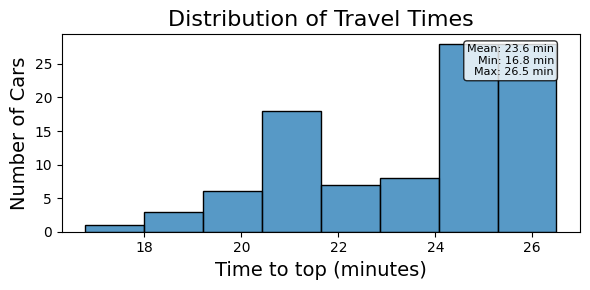

,AgentID,AgentType,created_at_step,steps_taken,car_interactions,distance_traveled,approx_average_mph,performance,curve_responce,acceptable_over,ideal_distance_multiplier,follow_ft_at50mph,travel_time,steps_behind_previous,pct_car_interactions
97,603,CarAgent,411,1582,336,19958.01,28.22,0.470864,0.771616,5.53,0.98,71.72,00:26,1,0.212389
98,605,CarAgent,412,1583,425,19950.15,28.19,0.124092,0.681485,11.71,0.89,65.62,00:26,1,0.268478


In [51]:
finished_agents = au.finished_agents_summary_df(tm, plots=True)

finished_agents.head(2)

finished_agents.tail(2)

In [53]:
for k, v in tm.datacollector.model_vars.items():
    print(k, len(v))

FinishedAgentsSummary 201
Step 200
current_toll_car 200
person_counter 200
bus_counter 200
car_counter 200
bus_riders 200


In [52]:
tm.datacollector.get_model_vars_dataframe()

ValueError: All arrays must be of the same length

In [ ]:
# process the finished_agents data 
vehicles_full = au.vehicle_agent_data_time_series(tm, plots=True)
model_ts = au.model_data_time_series(tm)

In [ ]:
model_ts

# Annimations

In [ ]:
# run the animation
# looking at one car
issue_car_id =  604
issue_step = 0

In [ ]:
anim.animate_traffic(vehicles_full, road_gdf, interval=100, step_skip=2, watch=None, zoom=20)

In [ ]:
anim.animate_traffic_with_speed_delta_highlight(vehicles_full, road_gdf, model_ts, interval=100, step_skip=3, watch=None, zoom=20)

In [ ]:
anim.animate_relative_distance(vehicle_df=vehicles_full, agent_id=700, distance_behind=100, color_by='status')